# 08. 최종 시각화 (Final Visualization)

**기준 시점: 2025Q4**

이 notebook은 새로운 분석·모델링을 수행하지 않는다. `05_commercial_signal.ipynb`,
`06_peer_benchmark.ipynb`, `07_strategy_recommendation.ipynb`에서 이미 산출된 결과를
읽어와 발표 자료·README·공모전 자료에 바로 활용할 수 있는 형태로 시각화하는 것만이
목적이다.

## 이 notebook이 하지 않는 것

- 새로운 feature engineering
- Isolation Forest / Nearest Neighbor 재학습, peer 재선정
- diagnosis_type / priority_level / strategy / threshold 신규 정의·재계산
- 01~07 notebook 또는 `data/processed` 산출물 수정

## 이 notebook이 하는 것

- `hwanghak_peer_benchmark.csv`, `hwanghak_strategy_recommendation.csv`에 이미 저장된
  값을 읽고 검증한다.
- 동일한 값을 `wide → long` 형태로 reshape하거나(예: `melt`), 이미 존재하는 컬럼을
  그대로 그래프·표로 표현한다.
- 핵심 figure를 `reports/figures/`에 PNG로 저장한다.

## 전체 분석 흐름 속 위치

```text
01_data_understanding → 02_preprocessing → 03_eda → 04_feature_engineering
→ 05_commercial_signal (Isolation Forest 이상 변화 탐지)
→ 06_peer_benchmark (Nearest Neighbor 구조적 유사 상권 탐색 + Peer Benchmark)
→ 07_strategy_recommendation (Rule-based Diagnosis → Policy Priority → Strategy → KPI)
→ 08_final_visualization (본 notebook: 최종 시각화)
```


## 1. 라이브러리 및 경로 설정

`pandas`, `numpy`, `matplotlib`, `seaborn`, `pathlib.Path`만 사용한다. 새로운
dependency는 추가하지 않는다.

In [1]:
import textwrap
import warnings
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

pd.set_option("display.max_colwidth", 120)

In [2]:
PROCESSED_DIR = Path("../data/processed")
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_PATH = PROCESSED_DIR / "hwanghak_strategy_recommendation.csv"
BENCHMARK_PATH = PROCESSED_DIR / "hwanghak_peer_benchmark.csv"

for p in [STRATEGY_PATH, BENCHMARK_PATH]:
    assert p.exists(), f"입력 파일이 존재하지 않습니다: {p}"

print("입력 파일 확인 완료")
print(" -", STRATEGY_PATH)
print(" -", BENCHMARK_PATH)
print(" - figure 저장 경로:", FIGURE_DIR)

입력 파일 확인 완료
 - ..\data\processed\hwanghak_strategy_recommendation.csv
 - ..\data\processed\hwanghak_peer_benchmark.csv
 - figure 저장 경로: ..\reports\figures


## 2. 데이터 로드 및 검증

06/07에서 저장한 두 CSV만 사용한다. 05의 원본 signal 파일(`commercial_signals.csv`)은
07 결과에 AI/ML signal 컬럼(`structural_change_score`, `decoupling_score`,
`anomaly_percentile`, `change_intensity_score` 등)이 이미 포함되어 있으므로 중복 로드하지
않는다.

- `hwanghak_strategy_recommendation.csv`: 07의 최종 산출물 (4 rows × 42 columns).
  diagnosis / priority / strategy / KPI / 핵심 지표 값을 담고 있다.
- `hwanghak_peer_benchmark.csv`: 06의 산출물. target 값과 함께
  `{metric}_peer_median`, `{metric}_peer_gap`, `{metric}_peer_flag`(HIGH/TYPICAL/LOW)를
  담고 있어 Figure 2·3·4에서 사용한다.

In [3]:
strategy_df = pd.read_csv(STRATEGY_PATH, encoding="utf-8-sig")
benchmark_df = pd.read_csv(BENCHMARK_PATH, encoding="utf-8-sig")

print("strategy_df shape:", strategy_df.shape)
print("benchmark_df shape:", benchmark_df.shape)

strategy_df shape: (4, 42)
benchmark_df shape: (4, 131)


In [4]:
AREA_CODE_COL = "상권_코드"
AREA_NAME_COL = "상권_코드_명"
AREA_TYPE_COL = "상권_구분_코드_명"

REQUIRED_STRATEGY_COLS = [
    AREA_CODE_COL, AREA_NAME_COL, AREA_TYPE_COL,
    "diagnosis_type", "priority_level",
    "strategy_1", "strategy_basis_1",
    "strategy_2", "strategy_basis_2",
    "strategy_3", "strategy_basis_3",
    "outcome_kpi_1", "outcome_kpi_2", "outcome_kpi_3",
    "diagnostic_kpi_1", "diagnostic_kpi_2", "diagnostic_kpi_3",
]
missing_cols = [c for c in REQUIRED_STRATEGY_COLS if c not in strategy_df.columns]
assert not missing_cols, f"strategy_df에 필요한 컬럼이 없습니다: {missing_cols}"

assert strategy_df.shape[0] == 4, f"황학동 상권 수가 4개가 아닙니다: {strategy_df.shape[0]}"
assert strategy_df[AREA_CODE_COL].is_unique, "상권_코드가 중복됩니다."
assert strategy_df["diagnosis_type"].notna().all(), "diagnosis_type에 결측이 있습니다."
assert strategy_df["priority_level"].notna().all(), "priority_level에 결측이 있습니다."
for col in ["strategy_1", "strategy_2", "strategy_3"]:
    assert strategy_df[col].notna().all(), f"{col}에 결측이 있습니다."

assert benchmark_df.shape[0] == 4, f"benchmark_df 상권 수가 4개가 아닙니다: {benchmark_df.shape[0]}"
assert benchmark_df["target_code"].is_unique, "benchmark_df target_code가 중복됩니다."
assert set(strategy_df[AREA_CODE_COL]) == set(benchmark_df["target_code"]), (
    "strategy_df와 benchmark_df의 상권 코드 집합이 다릅니다."
)

print("검증 통과: 상권 수 = 4, 상권코드 unique, diagnosis_type/priority_level/strategy 결측 없음")
strategy_df[[AREA_CODE_COL, AREA_NAME_COL, AREA_TYPE_COL, "diagnosis_type", "priority_level"]]

검증 통과: 상권 수 = 4, 상권코드 unique, diagnosis_type/priority_level/strategy 결측 없음


,상권_코드,상권_코드_명,상권_구분_코드_명,diagnosis_type,priority_level
0,3110055,황학동벼룩시장,골목상권,매출-유동인구 괴리형,중간
1,3110057,황학코아루아파트,골목상권,상대적 안정·우위형,낮음
2,3130054,황학동주방가구거리상점가,전통시장,구조 변화·업종 재편형,높음
3,3130055,"황학시장(서울중앙시장, 신중앙시장)",전통시장,동반 하락형,높음


In [5]:
# 4개 상권의 표시 순서를 이후 모든 그림에서 고정한다.
# 새로운 이름 mapping을 만들지 않고, 07 결과에 저장된 상권_코드/상권_코드_명을 그대로 사용한다.
AREA_ORDER = strategy_df[AREA_CODE_COL].tolist()
AREA_NAME_MAP = dict(zip(strategy_df[AREA_CODE_COL], strategy_df[AREA_NAME_COL]))

print("고정된 상권 표시 순서:")
for code_ in AREA_ORDER:
    print(f" - {code_}: {AREA_NAME_MAP[code_]}")

고정된 상권 표시 순서:
 - 3110055: 황학동벼룩시장
 - 3110057: 황학코아루아파트
 - 3130054: 황학동주방가구거리상점가
 - 3130055: 황학시장(서울중앙시장, 신중앙시장)


## 3. 시각화 공통 설정

### 3.1 한글 폰트

설치된 폰트 중 `Malgun Gothic` → `AppleGothic` → `NanumGothic` 순으로 사용 가능한 것을
선택한다. 새로 폰트를 설치하지 않으며, 후보가 전혀 없으면 경고만 출력하고 실행은 계속한다.

In [6]:
KOREAN_FONT_CANDIDATES = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((f for f in KOREAN_FONT_CANDIDATES if f in available_fonts), None)

if selected_font is None:
    warnings.warn(
        "한글 폰트 후보(Malgun Gothic/AppleGothic/NanumGothic)를 찾지 못했습니다. "
        "그래프의 한글 라벨이 깨질 수 있습니다."
    )
else:
    plt.rcParams["font.family"] = selected_font

plt.rcParams["axes.unicode_minus"] = False
print("선택된 한글 폰트:", selected_font)

선택된 한글 폰트: Malgun Gothic


### 3.2 색상·디자인 토큰

발표용 일관성을 위해 아래 색상 규칙을 모든 figure에서 공통으로 사용한다.

| 용도 | 규칙 |
|---|---|
| 4개 상권 정체성(identity) | `AREA_COLORS` (파랑·주황·아쿠아·노랑) — 상권 순서는 `AREA_ORDER`로 고정 |
| 4개 지표 구분(매출/거래건수/점포수/유동인구) | `METRIC_COLORS` (마젠타·초록·보라·빨강) — `AREA_COLORS`와 색상군을 겹치지 않게 분리 |
| 정책 우선순위(낮음/중간/높음) | `PRIORITY_COLORS` — 초록(good)/노랑(warning)/빨강(critical) |
| peer 비교 상태(HIGH/TYPICAL/LOW) | `PEER_FLAG_COLORS` — 파랑(peer 대비 높음)/회색(유사)/빨강(peer 대비 낮음). 가치판단이 아니라 상대적 위치를 의미한다. |
| 증가/감소(부호) | `DIVERGING_CMAP` — 빨강(음) ↔ 회색(0) ↔ 파랑(양) diverging colormap |

`AREA_COLORS`(상권 identity)와 `METRIC_COLORS`(지표 구분)는 같은 그림에서 동시에 등장할
수 있으므로(Figure 1은 지표 색, Figure 4·7·9는 상권 색을 사용), 두 팔레트가 같은 색상을
공유하지 않도록 명확히 분리한다. 예를 들어 파랑이 Figure 4에서는 "황학동벼룩시장"을
의미하는데 Figure 1에서는 "매출 YoY"를 의미하면 같은 색이 서로 다른 뜻을 갖게 되므로,
두 목적을 완전히 다른 hue로 나눈다.

In [7]:
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
BASELINE_COLOR = "#c3c2b7"
SURFACE_COLOR = "#fcfcfb"

# 4개 상권 정체성(identity) 색상 - AREA_ORDER와 같은 순서로 매핑, 모든 그림에서 재사용
AREA_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # 파랑·주황·아쿠아·노랑
AREA_COLOR_MAP = dict(zip(AREA_ORDER, AREA_COLORS))

# 4개 지표(매출/거래건수/점포수/유동인구) 구분 색상 - AREA_COLORS와 hue를 겹치지 않게 분리해
# "파랑 = 특정 상권"과 "파랑 = 특정 지표"가 서로 다른 그림에서 충돌하지 않도록 한다.
METRIC_COLORS = {
    "매출": "#e87ba4",      # 마젠타
    "거래건수": "#008300",  # 초록
    "점포수": "#4a3aa7",    # 보라
    "유동인구": "#e34948",  # 빨강
}

# 정책 우선순위(priority_level) 상태 색상 - 낮음/중간/높음
PRIORITY_COLORS = {"낮음": "#0ca30c", "중간": "#fab219", "높음": "#d03b3b"}

# peer 비교 상태(HIGH/TYPICAL/LOW) 색상 - "peer 대비 위/유사/아래"를 의미하며 가치판단이 아니다.
PEER_FLAG_COLORS = {"HIGH": "#2a78d6", "TYPICAL": "#898781", "LOW": "#e34948"}

# 증가/감소(부호)를 나타낼 때 사용하는 2색 + 중립색
DIVERGING_POS = "#2a78d6"
DIVERGING_NEG = "#e34948"
DIVERGING_MID = "#f0efec"
DIVERGING_CMAP = sns.blend_palette([DIVERGING_NEG, DIVERGING_MID, DIVERGING_POS], as_cmap=True)

plt.rcParams.update({
    "figure.facecolor": SURFACE_COLOR,
    "axes.facecolor": SURFACE_COLOR,
    "axes.edgecolor": BASELINE_COLOR,
    "axes.grid": False,
    "text.color": INK_PRIMARY,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
})

### 3.3 단위 변환 helper 및 figure 저장 helper

`format_pct`/`format_pp`는 값을 변형하지 않고 **표시용 문자열만** 만든다. YoY·peer gap
컬럼은 이미 `%`/`%p` 스케일(예: `74.3`)로 저장되어 있으므로 다시 `×100`을 하지 않는다
(바로 다음 셀에서 실제 값 범위를 확인한다).

In [8]:
# 이미 % 스케일(예: 74.3 -> +74.3%)인 값을 부호 포함 문자열로 표시한다.
def format_pct(value, decimals=1):
    if pd.isna(value):
        return "N/A"
    return f"{value:+.{decimals}f}%"


# peer gap 등 %p 스케일 값을 부호 포함 문자열로 표시한다.
def format_pp(value, decimals=1):
    if pd.isna(value):
        return "N/A"
    return f"{value:+.{decimals}f}%p"


# 0~1 스케일 비율(share)을 %로 변환해 표시한다. 원본 값은 그대로 두고 표시할 때만 변환한다.
def ratio_to_pct(value, decimals=1):
    if pd.isna(value):
        return "N/A"
    return f"{value * 100:.{decimals}f}%"


# 0~100 범위의 AI/ML 상대 점수(예: structural_change_score)를 표시한다.
# 통계적으로 엄밀한 percentile인 컬럼은 anomaly_percentile뿐이므로, 그 외 score는
# "percentile"이 아니라 "상대 점수"로 표현한다.
def format_score(value, decimals=1, unit="점"):
    if pd.isna(value):
        return "N/A"
    return f"{value:.{decimals}f}{unit}"


# 긴 한글 문장을 여러 줄로 자동 줄바꿈한다(단어 단위로만 자르고, 단어 중간을 끊지 않는다).
def wrap_text(text, width=9):
    return "\n".join(textwrap.wrap(str(text), width=width, break_long_words=False, break_on_hyphens=False))


saved_figures = []


def save_fig(fig, filename, dpi=300):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    saved_figures.append(path)
    print("저장:", path)

### 3.4 데이터 단위(스케일) 확인

`%`, `%p`, `percentile`, 0~1 비율(share)이 섞여 있으므로, 그래프를 그리기 전에 각 그룹의
실제 값 범위를 먼저 확인한다.

In [9]:
YOY_COLS = ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]
SHARE_COLS = [
    "weekend_sales_share", "evening_night_sales_share", "top1_industry_share",
    "furniture_sales_share", "korean_food_sales_share", "ecommerce_sales_share",
]
SCORE_COLS = ["structural_change_score", "decoupling_score", "anomaly_percentile", "change_intensity_score"]

print("[YoY 지표] strategy_df 값 범위 (이미 % 단위인지 확인)")
print(strategy_df[YOY_COLS].agg(["min", "max"]).T, "\n")

print("[share류 지표] benchmark_df 값 범위 (0~1 비율인지 확인)")
print(benchmark_df[SHARE_COLS].agg(["min", "max"]).T, "\n")

print("[AI/ML Signal] strategy_df 값 범위 (0~100 상대 점수)")
print(strategy_df[SCORE_COLS].agg(["min", "max"]).T)

[YoY 지표] strategy_df 값 범위 (이미 % 단위인지 확인)
                        min        max
sales_yoy        -18.098214  74.344454
transactions_yoy -24.712467  19.382366
stores_yoy        -2.732240   2.577320
population_yoy   -30.175085   3.491111 

[share류 지표] benchmark_df 값 범위 (0~1 비율인지 확인)
                                min       max
weekend_sales_share        0.202805  0.817985
evening_night_sales_share  0.072583  0.548598
top1_industry_share        0.322017  0.797896
furniture_sales_share      0.000000  0.568545
korean_food_sales_share    0.085664  0.598803
ecommerce_sales_share      0.000000  0.797896 

[AI/ML Signal] strategy_df 값 범위 (0~100 상대 점수)
                               min        max
structural_change_score  37.254650  70.891597
decoupling_score         20.853741  79.634010
anomaly_percentile       12.347267  99.099678
change_intensity_score   37.253173  61.177893


위 결과를 보면 `sales_yoy` 등 YoY 지표는 이미 `74.3`처럼 % 스케일로 저장되어 있어
**다시 ×100 하지 않고 그대로 `%`로 표시**한다. `weekend_sales_share` 등 share류 지표는
`0~1` 비율이므로 **표시할 때만 ×100**한다(`ratio_to_pct`). `structural_change_score` 등
AI/ML Signal은 `0~100` 범위의 **상대 점수**다(`anomaly_percentile`만 예외적으로 실제
percentile). 표시 단위는 이후 모든 figure에서 `%`(YoY·share) / `%p`(peer gap) /
`점`(AI/ML 상대 점수)으로 통일한다.

## 4. Figure 1 — 황학동 4개 상권 핵심 성과 비교

**사용 컬럼**: `strategy_df`의 `sales_yoy`, `transactions_yoy`, `stores_yoy`,
`population_yoy` (07 결과를 그대로 사용, 재계산 없음).

2025Q4 기준 황학동 4개 상권의 매출·거래건수·점포수·유동인구가 전년 대비 어떻게
변화했는지를 grouped horizontal bar chart로 비교한다. `x=0` 기준선으로 증가/감소를
구분한다. 이 그림은 4개 상권이 아니라 **4개 지표**를 색으로 구분하므로, 상권 identity
색상(`AREA_COLORS`)이 아니라 별도의 `METRIC_COLORS`를 사용한다(같은 파랑이 다른 그림에서
"특정 상권"과 "매출 YoY"를 동시에 의미하지 않도록 분리).

저장: ..\reports\figures\01_hwanghak_yoy_performance.png


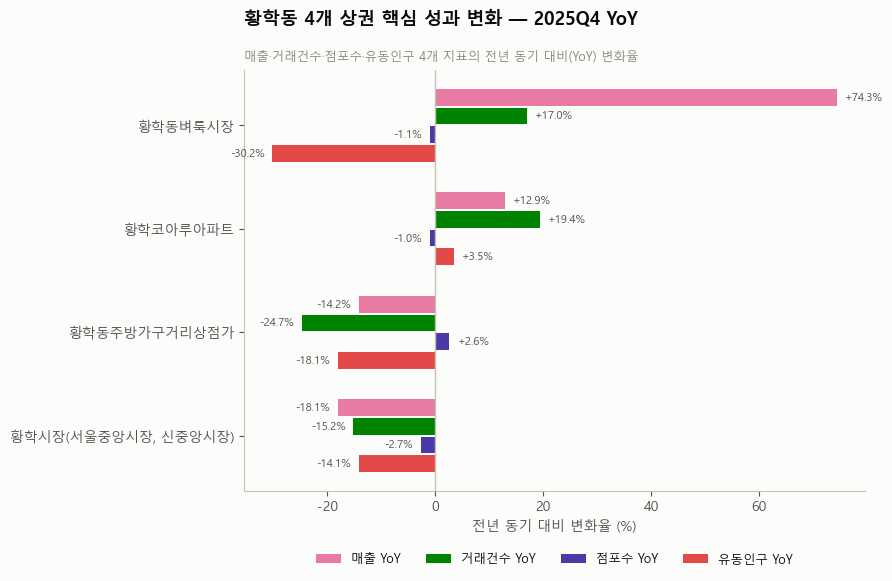

,sales_yoy,transactions_yoy,stores_yoy,population_yoy
상권_코드,,,,
3110055,74.344454,17.017110,-1.063830,-30.175085
3110057,12.866359,19.382366,-0.980392,3.491111
3130054,-14.226812,-24.712467,2.577320,-18.050908
3130055,-18.098214,-15.159699,-2.732240,-14.131048


In [10]:
FIG1_METRICS = ["sales_yoy", "transactions_yoy", "stores_yoy", "population_yoy"]
FIG1_METRIC_LABELS = {
    "sales_yoy": "매출 YoY",
    "transactions_yoy": "거래건수 YoY",
    "stores_yoy": "점포수 YoY",
    "population_yoy": "유동인구 YoY",
}
# 상권 identity 색상(AREA_COLORS)과 겹치지 않도록 METRIC_COLORS에서 지표별 색을 가져온다.
FIG1_METRIC_SHORT_LABELS = {
    "sales_yoy": "매출", "transactions_yoy": "거래건수",
    "stores_yoy": "점포수", "population_yoy": "유동인구",
}
FIG1_METRIC_COLORS = {col: METRIC_COLORS[short] for col, short in FIG1_METRIC_SHORT_LABELS.items()}

fig1_df = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, FIG1_METRICS]

n_metrics = len(FIG1_METRICS)
n_areas = len(AREA_ORDER)
bar_height = 0.18
y_base = np.arange(n_areas)

fig, ax = plt.subplots(figsize=(9, 6))
for i, metric in enumerate(FIG1_METRICS):
    offsets = y_base + (i - (n_metrics - 1) / 2) * bar_height
    values = fig1_df[metric].values
    ax.barh(offsets, values, height=bar_height * 0.9,
            color=FIG1_METRIC_COLORS[metric], label=FIG1_METRIC_LABELS[metric])
    for y, v in zip(offsets, values):
        align = "left" if v >= 0 else "right"
        pad = 1.5 if v >= 0 else -1.5
        ax.text(v + pad, y, format_pct(v), va="center", ha=align, fontsize=8, color=INK_SECONDARY)

ax.axvline(0, color=BASELINE_COLOR, linewidth=1)
ax.set_yticks(y_base)
ax.set_yticklabels([AREA_NAME_MAP[c] for c in AREA_ORDER])
ax.invert_yaxis()
ax.set_xlabel("전년 동기 대비 변화율 (%)")
ax.set_title("황학동 4개 상권 핵심 성과 변화 — 2025Q4 YoY", fontsize=13, fontweight="bold", loc="left", y=1.09)
ax.text(0, 1.02, "매출·거래건수·점포수·유동인구 4개 지표의 전년 동기 대비(YoY) 변화율",
        transform=ax.transAxes, fontsize=9, color=INK_MUTED)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=9)

fig.tight_layout()
save_fig(fig, "01_hwanghak_yoy_performance.png")
plt.show()

fig1_df

**관찰**: 황학동벼룩시장은 매출 YoY가 +74.3%로 4개 상권 중 가장 크게 증가했지만
유동인구 YoY는 -30.2%로 가장 크게 감소해, 두 지표의 변화 방향이 동시에 반대로
관측된다. 황학코아루아파트는 매출(+12.9%)·거래건수(+19.4%)·유동인구(+3.5%)가 모두
양(+)의 방향으로 나타난다. 황학동주방가구거리상점가와 황학시장은 매출·거래건수·유동인구가
모두 음(-)의 방향으로 나타나며, 점포수 변화의 방향은 두 상권이 서로 다르다(주방가구거리
+2.6% vs 황학시장 -2.7%).

## 5. Figure 2 — Target vs Peer Benchmark

**사용 컬럼**: `benchmark_df`의 `{metric}_peer_median`, `{metric}_peer_gap`
(06에서 이미 계산된 값을 그대로 사용, 재계산 없음).

이 프로젝트의 핵심 차별점인 peer benchmark를 dumbbell plot(target vs peer median)으로
보여준다. 4개 metric을 2×2 subplot으로 나눠 한 그래프에 무리하게 담지 않는다.

> Peer gap은 구조적으로 유사한 상권 대비 현재 변화의 상대적 위치를 보여주는
> descriptive benchmark이며, 정책 효과나 인과효과를 의미하지 않는다.

저장: ..\reports\figures\02_target_vs_peer.png


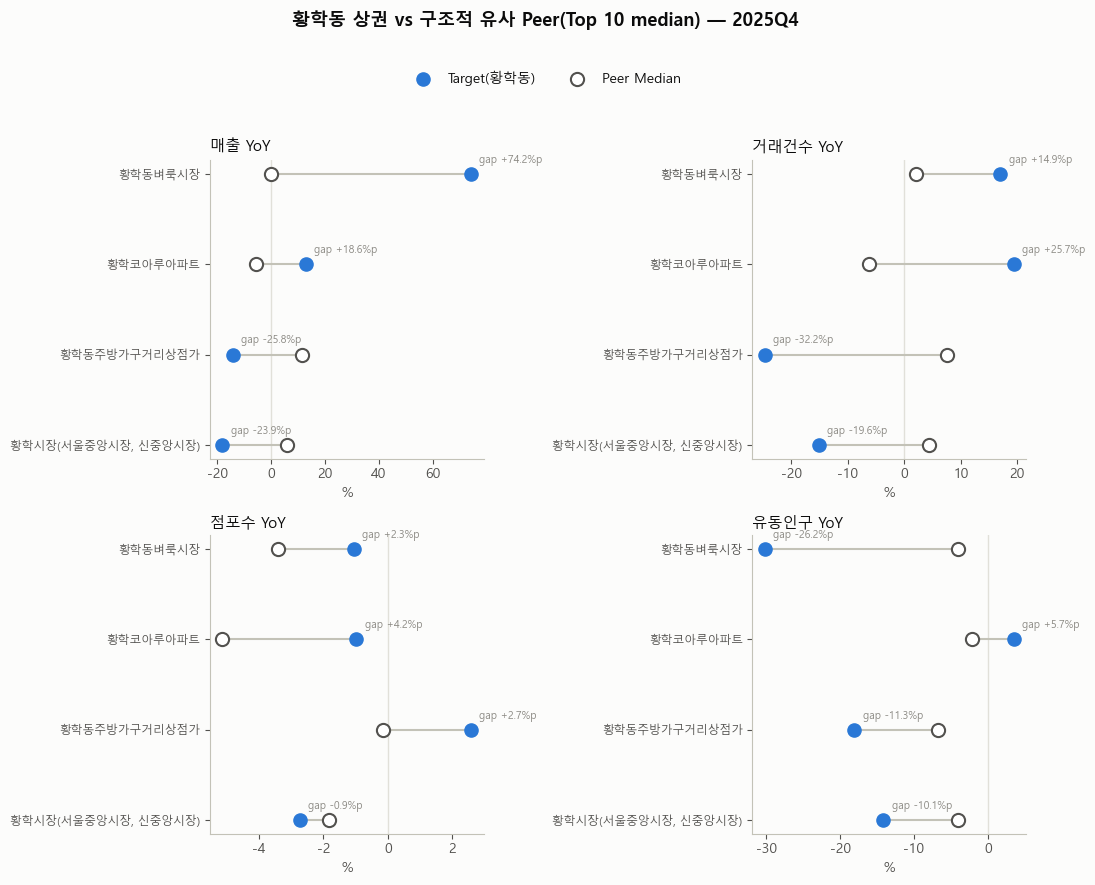

In [11]:
FIG2_METRICS = FIG1_METRICS
bm_indexed = benchmark_df.set_index("target_code").loc[AREA_ORDER]

y_pos = np.arange(len(AREA_ORDER))
area_labels = [AREA_NAME_MAP[c] for c in AREA_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, metric in zip(axes, FIG2_METRICS):
    target_vals = bm_indexed[metric].values
    peer_vals = bm_indexed[f"{metric}_peer_median"].values
    gap_vals = bm_indexed[f"{metric}_peer_gap"].values

    for y, t, p in zip(y_pos, target_vals, peer_vals):
        ax.plot([p, t], [y, y], color=BASELINE_COLOR, linewidth=1.5, zorder=1)
    ax.scatter(target_vals, y_pos, s=90, color=DIVERGING_POS, label="Target(황학동)", zorder=3)
    ax.scatter(peer_vals, y_pos, s=90, facecolors="white", edgecolors=INK_SECONDARY,
               linewidths=1.5, label="Peer Median", zorder=3)
    for y, t, g in zip(y_pos, target_vals, gap_vals):
        ax.annotate(f"gap {format_pp(g)}", xy=(t, y), xytext=(6, 8),
                    textcoords="offset points", fontsize=7.5, color=INK_MUTED)

    ax.axvline(0, color=GRID_COLOR, linewidth=1, zorder=0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(area_labels, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel("%")
    ax.set_title(FIG1_METRIC_LABELS[metric], fontsize=11, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False, fontsize=10)
fig.suptitle("황학동 상권 vs 구조적 유사 Peer(Top 10 median) — 2025Q4", fontsize=13, fontweight="bold", y=1.1)
fig.tight_layout()
save_fig(fig, "02_target_vs_peer.png")
plt.show()

**관찰**: 황학동벼룩시장은 매출 YoY가 peer median 대비 +74.2%p 높게 나타나 4개
상권 중 peer gap이 가장 크며, 유동인구 YoY는 peer median 대비 -26.2%p 낮게
관측된다. 황학코아루아파트는 매출(+18.6%p)·거래건수(+25.7%p)·유동인구(+5.7%p) 모두
peer 대비 양(+)의 gap을 보인다. 황학동주방가구거리상점가와 황학시장은 매출·거래건수·
유동인구 peer gap이 모두 음(-)으로 나타나, 구조적으로 유사한 상권들과 비교했을 때도
상대적으로 낮은 변화를 보인다. 다시 강조하면, 이 gap은 정책 적용 시 개선 가능량을
의미하지 않는다.

## 6. Figure 3 — Peer Gap Heatmap

**사용 컬럼**: `strategy_df`의 `{metric}_yoy_peer_gap` (06에서 계산된 값을 그대로 사용).

행 = 황학동 4개 상권, 열 = 매출/거래건수/점포수/유동인구, 값 = target 변화율 - peer
median 변화율. 색상 중심값은 0으로 두고, 컬러바 라벨은 `Peer gap (%p)`로 표시한다.

저장: ..\reports\figures\03_peer_gap_heatmap.png


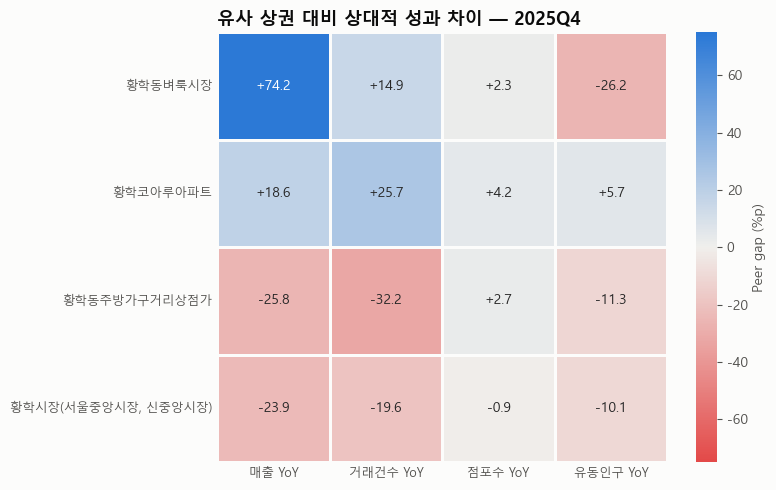

In [12]:
FIG3_METRICS = FIG1_METRICS
FIG3_COL_LABELS = [FIG1_METRIC_LABELS[m] for m in FIG3_METRICS]

heat_data = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, [f"{m}_peer_gap" for m in FIG3_METRICS]].copy()
heat_data.columns = FIG3_COL_LABELS
heat_data.index = [AREA_NAME_MAP[c] for c in AREA_ORDER]

vmax = float(np.ceil(heat_data.abs().to_numpy().max()))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat_data, cmap=DIVERGING_CMAP, center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt="+.1f", linewidths=2, linecolor=SURFACE_COLOR,
            cbar_kws={"label": "Peer gap (%p)"}, annot_kws={"fontsize": 10}, ax=ax)
ax.set_title("유사 상권 대비 상대적 성과 차이 — 2025Q4", fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=9, length=0)
fig.tight_layout()
save_fig(fig, "03_peer_gap_heatmap.png")
plt.show()

**관찰**: 매출 peer gap은 황학동벼룩시장(+74.2%p)에서 가장 크게 양(+)이고,
유동인구 peer gap은 같은 상권에서 가장 크게 음(-)(-26.2%p)이어서 한 상권 안에서도
지표에 따라 상반된 색으로 나타난다. 황학동주방가구거리상점가와 황학시장은 대부분의
셀이 음(-) 방향(붉은 계열)으로 나타나 peer 대비 낮은 변화가 여러 지표에 걸쳐
동시에 관측된다.

## 7. Figure 4 — AI/ML 변화 Signal 비교

**사용 컬럼**: `strategy_df`의 `structural_change_score`, `decoupling_score`,
`anomaly_percentile`, `change_intensity_score` (05에서 계산되어 07까지 전달된 값,
재계산 없음). 4개 지표는 서로 다른 구성요소로 계산된 **0~100 범위의 상대적 AI/ML
Signal(점수)**이라 하나의 축에 그대로 겹쳐 그리지 않고(임의 정규화 없이) **2×2 개별
subplot**으로 분리한다(방법 A).

- `structural_change_score`: 변화의 방향이 아니라 **강도**를 나타내는 상대 점수.
- `decoupling_score`: 매출 변화와 유동인구/점포수 변화가 얼마나 엇갈리는지를 나타내는
  상대 점수.
- `anomaly_percentile`: Isolation Forest anomaly score를 서울 동일 분기 상권 대비
  percentile로 변환한 값 — 4개 지표 중 유일하게 통계적으로 엄밀한 percentile이다.
- `change_intensity_score`: 위 세 축(구조 변화·괴리·변동성)의 평균 상대 점수.

네 지표 모두 "값이 클수록 변화/이상성이 크다"는 방향은 같지만, 서로 다른 구성요소의
평균이라 엄밀한 percentile은 아니므로 그래프 제목과 본문에서는 `0~100 상대 점수`로
통일해서 표현한다(`anomaly_percentile`만 예외적으로 실제 percentile). 막대 아래 텍스트는
`benchmark_df`의 `{metric}_peer_flag`(HIGH/TYPICAL/LOW)를 그대로 표시한 것이며, 숫자가
아니라 **범주 표시용**이다. 05~07 어디에도 이 네 지표에 대한 "50점" 판정 threshold는
정의되어 있지 않으므로, 그래프 중앙을 표시하기 위한 임의의 기준선은 넣지 않는다.

저장: ..\reports\figures\04_ai_signal_comparison.png


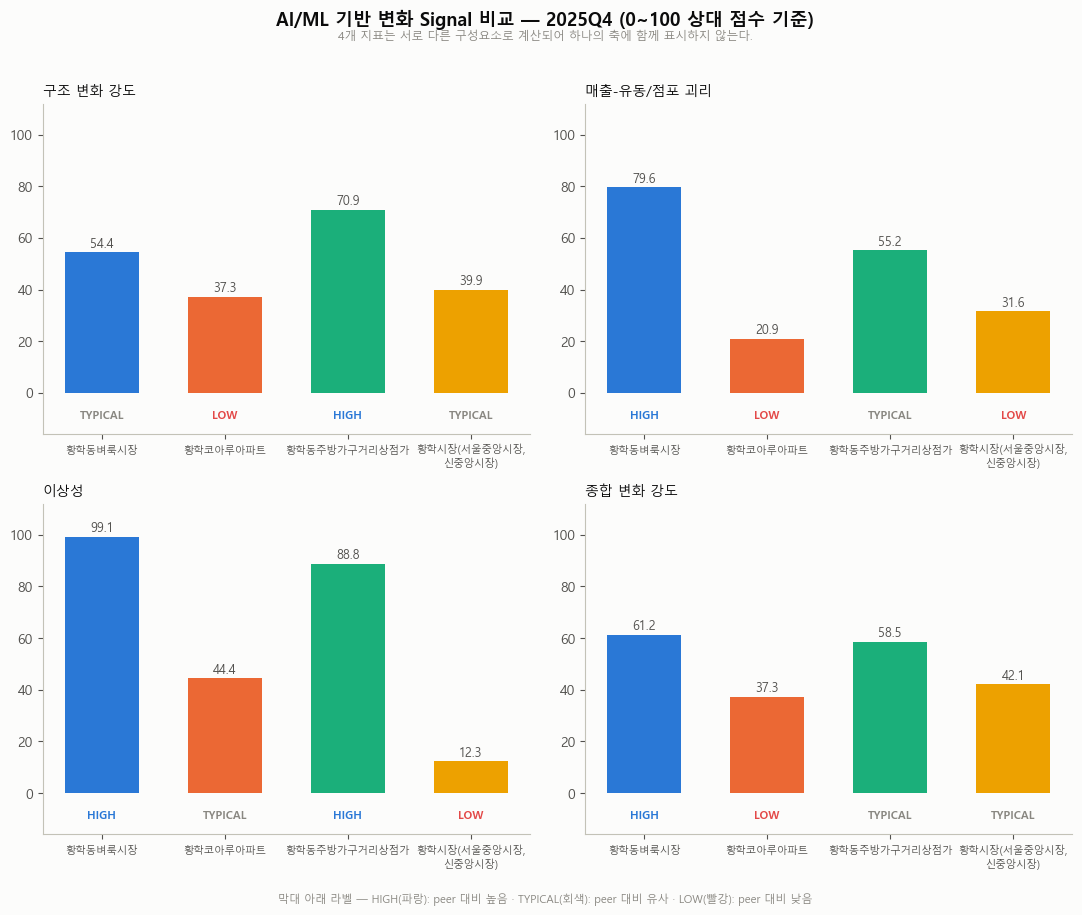

In [13]:
FIG4_METRICS = ["structural_change_score", "decoupling_score", "anomaly_percentile", "change_intensity_score"]
FIG4_TITLES = {
    "structural_change_score": "구조 변화 강도",
    "decoupling_score": "매출-유동/점포 괴리",
    "anomaly_percentile": "이상성",
    "change_intensity_score": "종합 변화 강도",
}

x_pos = np.arange(len(AREA_ORDER))
bar_colors = [AREA_COLOR_MAP[c] for c in AREA_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
axes = axes.flatten()

for ax, metric in zip(axes, FIG4_METRICS):
    values = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, metric].values
    flags = bm_indexed[f"{metric}_peer_flag"].values
    ax.bar(x_pos, values, color=bar_colors, width=0.6, zorder=3)
    for x, v, flag in zip(x_pos, values, flags):
        ax.text(x, v + 2, format_score(v, unit=""), ha="center", fontsize=9, color=INK_SECONDARY)
        ax.text(x, -10, flag, ha="center", fontsize=8, fontweight="bold",
                color=PEER_FLAG_COLORS.get(flag, INK_MUTED))
    ax.set_ylim(-16, 112)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([wrap_text(AREA_NAME_MAP[c], 7) for c in AREA_ORDER], fontsize=7.5)
    ax.set_title(FIG4_TITLES[metric], fontsize=10, loc="left")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("AI/ML 기반 변화 Signal 비교 — 2025Q4 (0~100 상대 점수 기준)",
             fontsize=13, fontweight="bold", y=1.03)
fig.text(0.5, 0.995,
         "4개 지표는 서로 다른 구성요소로 계산되어 하나의 축에 함께 표시하지 않는다.",
         ha="center", fontsize=8.5, color=INK_MUTED)
fig.text(0.5, -0.02,
         "막대 아래 라벨 — HIGH(파랑): peer 대비 높음 · TYPICAL(회색): peer 대비 유사 · LOW(빨강): peer 대비 낮음",
         ha="center", fontsize=8, color=INK_MUTED)
fig.tight_layout()
save_fig(fig, "04_ai_signal_comparison.png")
plt.show()

**관찰**: 황학동벼룩시장은 `anomaly_percentile`이 99.1로 4개 상권 중 가장 높고
peer 대비로도 HIGH로 나타나며, `decoupling_score`도 79.6으로 가장 높다. 이는 이례적인
변화 패턴일 가능성을 시사하지만, 그 자체로 좋다/나쁘다를 의미하지는 않는다.
황학동주방가구거리상점가는 `structural_change_score`가 70.9로 가장 높고 peer 대비
HIGH로 나타나, 구조적 변화의 강도가 상대적으로 크게 관측된다. 황학시장은 4개 지표
모두 상대적으로 낮은 편이며 peer 대비로도 TYPICAL/LOW가 대부분이다.

## 8. Figure 5 — 핵심 진단 Map

**사용 컬럼**: `strategy_df`의 `population_yoy`(x축), `sales_yoy`(y축),
`anomaly_percentile`(마커 크기), `priority_level`(색상).

이 그래프는 diagnosis 전체를 결정하는 공식 모델이 아니라, 4개 상권의 차이를
직관적으로 보여주는 **설명용 시각화**다. 실제 `diagnosis_type`은 07에서 `peer_flag`
기반 규칙(performance_axis/structural_axis/anomaly_axis)으로 이미 계산되어 있으며,
이 그래프는 그 결과를 재현하지 않고 그대로 참고 표시만 한다.

저장: ..\reports\figures\05_diagnosis_map.png


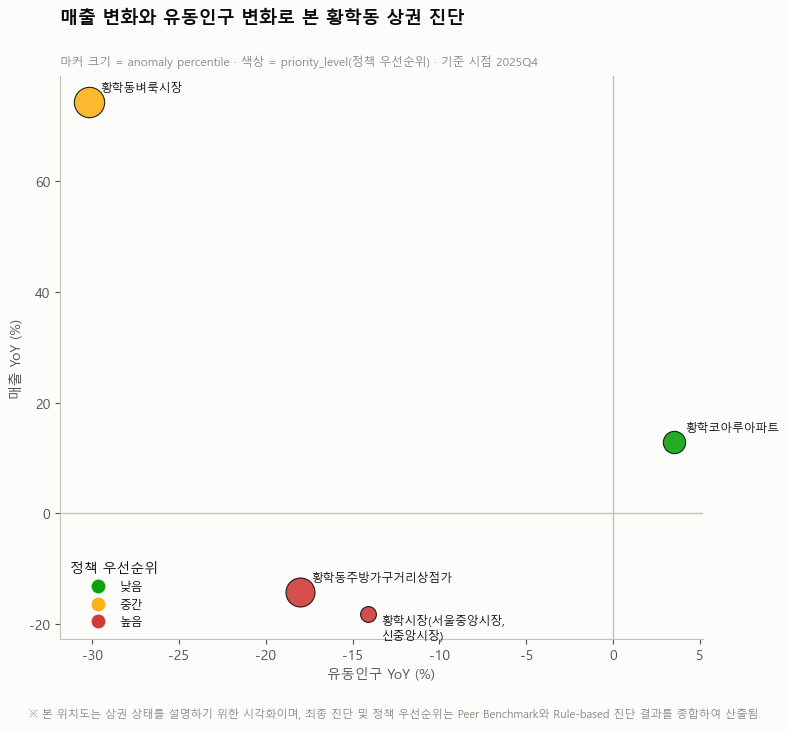

In [14]:
x_vals = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, "population_yoy"]
y_vals = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, "sales_yoy"]
size_vals = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, "anomaly_percentile"]
priority_vals = strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER, "priority_level"]
marker_sizes = 80 + size_vals * 4  # marker size = anomaly percentile (선형 스케일링, 표시 목적)

# 상권명 라벨이 서로 가까운 점끼리 겹치지 않도록, 상권별로 라벨 오프셋 방향을 다르게 둔다.
# 값을 바꾸는 것이 아니라 같은 값을 화면 어디에 적을지만 정하는 순수 레이아웃 설정이다.
FIG5_LABEL_OFFSETS = {0: (8, 8), 1: (8, 8), 2: (8, 8), 3: (10, -18)}

fig, ax = plt.subplots(figsize=(8, 7))
for i, code_ in enumerate(AREA_ORDER):
    x, y, s, p = x_vals[code_], y_vals[code_], marker_sizes[code_], priority_vals[code_]
    ax.scatter(x, y, s=s, color=PRIORITY_COLORS.get(p, INK_MUTED),
               edgecolors=INK_PRIMARY, linewidths=0.8, alpha=0.9, zorder=3)
    ax.annotate(wrap_text(AREA_NAME_MAP[code_], 10), xy=(x, y), xytext=FIG5_LABEL_OFFSETS[i],
                textcoords="offset points", fontsize=8.5, color=INK_PRIMARY)

ax.axhline(0, color=BASELINE_COLOR, linewidth=1)
ax.axvline(0, color=BASELINE_COLOR, linewidth=1)
ax.set_xlabel("유동인구 YoY (%)")
ax.set_ylabel("매출 YoY (%)")
ax.set_title("매출 변화와 유동인구 변화로 본 황학동 상권 진단", fontsize=13, fontweight="bold", loc="left", y=1.08)
ax.text(0, 1.02, "마커 크기 = anomaly percentile · 색상 = priority_level(정책 우선순위) · 기준 시점 2025Q4",
        transform=ax.transAxes, fontsize=8.5, color=INK_MUTED)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, markersize=9, label=lv)
                  for lv, c in PRIORITY_COLORS.items()]
ax.legend(handles=legend_handles, title="정책 우선순위", loc="lower left", frameon=False, fontsize=8.5)

fig.text(0.5, -0.03,
         "※ 본 위치도는 상권 상태를 설명하기 위한 시각화이며, 최종 진단 및 정책 우선순위는 "
         "Peer Benchmark와 Rule-based 진단 결과를 종합하여 산출됨.",
         ha="center", fontsize=8, color=INK_MUTED)

fig.tight_layout()
save_fig(fig, "05_diagnosis_map.png")
plt.show()

**관찰**: 황학동벼룩시장은 매출 YoY가 양(+)이면서 유동인구 YoY는 음(-)인
사분면에 위치해 두 지표의 변화 방향이 엇갈리는 모습을 보이며, anomaly percentile이
높아 마커 크기도 가장 크다. 황학코아루아파트는 매출·유동인구가 모두 양(+)인
사분면에 위치하고 정책 우선순위가 낮음으로 나타난다. 황학동주방가구거리상점가와
황학시장은 매출·유동인구가 모두 음(-)인 사분면에 위치하며 정책 우선순위가 높음으로
나타난다.

## 9. Figure 6 — Diagnosis / Priority Summary

**사용 컬럼**: `strategy_df`의 `상권_코드_명`, `diagnosis_type`, `priority_level`,
`peer_comparability_level` (07 결과를 그대로 표로 정리, 하드코딩 없음).

In [15]:
FIG6_COLS = {
    AREA_NAME_COL: "상권",
    "diagnosis_type": "진단 유형",
    "priority_level": "정책 우선순위",
    "peer_comparability_level": "Peer 비교 가능성",
}
fig6_df = (
    strategy_df.set_index(AREA_CODE_COL).loc[AREA_ORDER].reset_index()
    [list(FIG6_COLS)].rename(columns=FIG6_COLS)
)


def _priority_bg(val):
    color = PRIORITY_COLORS.get(val, "#ffffff")
    return f"background-color: {color}22"


styled_fig6 = (
    fig6_df.style
    .map(_priority_bg, subset=["정책 우선순위"])
    .set_properties(**{"text-align": "left"})
    .hide(axis="index")
)
styled_fig6

상권,진단 유형,정책 우선순위,Peer 비교 가능성
황학동벼룩시장,매출-유동인구 괴리형,중간,높음
황학코아루아파트,상대적 안정·우위형,낮음,높음
황학동주방가구거리상점가,구조 변화·업종 재편형,높음,낮음
"황학시장(서울중앙시장, 신중앙시장)",동반 하락형,높음,높음


저장: ..\reports\figures\06_diagnosis_priority_summary.png


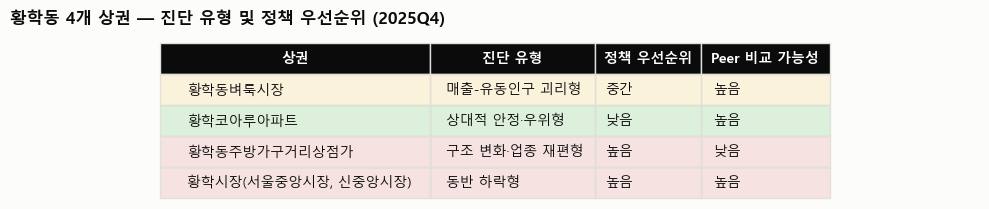

In [16]:
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis("off")
table = ax.table(cellText=fig6_df.values, colLabels=fig6_df.columns, cellLoc="left", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)
table.auto_set_column_width(col=list(range(len(fig6_df.columns))))

for (row, _col), cell in table.get_celld().items():
    cell.set_edgecolor(GRID_COLOR)
    if row == 0:
        cell.set_facecolor(INK_PRIMARY)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        priority_val = fig6_df.iloc[row - 1]["정책 우선순위"]
        cell.set_facecolor(PRIORITY_COLORS.get(priority_val, "#ffffff") + "22")

ax.set_title("황학동 4개 상권 — 진단 유형 및 정책 우선순위 (2025Q4)",
             fontsize=12, fontweight="bold", loc="left", pad=14)
fig.tight_layout()
save_fig(fig, "06_diagnosis_priority_summary.png")
plt.show()

## 10. Figure 7 — 상권별 문제 → 전략 연결

**사용 컬럼**: `strategy_df`의 `main_issue_1/2`, `strategy_1~3`, `strategy_basis_1~3`
(07에서 생성된 문장을 그대로 사용, 새로 작성하지 않음).

전략 문장이 길어 표보다 카드 형태가 더 적절하므로, 상세 내용은 먼저 텍스트로 출력하고
발표 자료용 요약 카드를 이어서 PNG로 저장한다. 카드 안에서는 `wrap_text()`로 긴 문장을
자동 줄바꿈하고, 실제로 소비한 줄 수만큼만 다음 줄로 내려가도록(고정 간격이 아니라
가변 간격으로) 배치해 텍스트가 카드 경계나 다른 카드 영역을 침범하지 않게 한다.
상권명(제목) → 진단/우선순위 → 핵심 문제 → 전략 순으로 글자 크기와 굵기를 달리해
시각적 위계를 명확히 한다.

In [17]:
for code_ in AREA_ORDER:
    row = strategy_df.set_index(AREA_CODE_COL).loc[code_]
    print(f"[{AREA_NAME_MAP[code_]}]")
    print(f"진단: {row['diagnosis_type']}")
    print(f"우선순위: {row['priority_level']}")
    print("핵심 문제:")
    for i, key in enumerate(["main_issue_1", "main_issue_2"], start=1):
        val = row.get(key)
        if pd.notna(val) and str(val).strip() not in ("", "-"):
            print(f"  {i}. {val}")
    for i in [1, 2, 3]:
        strat = row.get(f"strategy_{i}")
        basis = row.get(f"strategy_basis_{i}")
        if pd.notna(strat):
            print(f"전략 {i}: {strat}")
            if pd.notna(basis):
                print(f"  근거: {basis}")
    print("-" * 70)

[황학동벼룩시장]
진단: 매출-유동인구 괴리형
우선순위: 중간
핵심 문제:
  1. 유동인구 YoY peer 대비 낮음(peer gap -26.2%p)
  2. 이상성(anomaly) peer 대비 높음(peer gap +45.0p, 이례적 신호)
전략 1: 전자상거래 관련 매출 비중이 높은 특성을 활용해 온·오프라인 연계 프로그램의 적용 가능성 검토
  근거: ecommerce_sales_share가 peer 대비 +79.8%p 높게 관측되어, 온라인 채널 매출과 오프라인 방문을 연계할 근거가 있음
전략 2: 주말 매출 집중 특성을 활용한 주말 행사·체험 콘텐츠 강화 검토
  근거: weekend_sales_share가 peer 대비 +47.6%p 높게 관측되어, 주말 매출 집중 특성을 활용한 전략을 검토할 근거가 있음
전략 3: 매출 성과를 실제 방문으로 연결하는 방안 검토
  근거: 매출-유동인구 괴리형 진단 결과에 따른 기본 전략 방향
----------------------------------------------------------------------
[황학코아루아파트]
진단: 상대적 안정·우위형
우선순위: 낮음
핵심 문제:
  1. 핵심 성과지표(매출/거래/점포/유동인구)가 모두 peer 대비 양호하거나 유사해 데이터상 뚜렷한 문제는 확인되지 않음. 관리 포인트: top1_industry_share가 peer 대비 +15.2%p 높게 관측되어 단일 업종 의존도를 모니터링할 필요가 있음
전략 1: 단일 업종 편중에 따른 위험을 낮추기 위한 업종 다양성/구성 모니터링 검토
  근거: top1_industry_share가 peer 대비 +15.2%p 높게 관측되어, 업종 집중 위험을 모니터링할 근거가 있음
전략 2: 현재의 상대적 경쟁우위 유지
  근거: 상대적 안정·우위형 진단 결과에 따른 기본 전략 방향
전략 3: 기존 강점 확장 검토
  근거: 상대적 안정·우위형 진단 결과에 따른 기본 전략 방향
-------------------------

저장: ..\reports\figures\07_strategy_summary.png


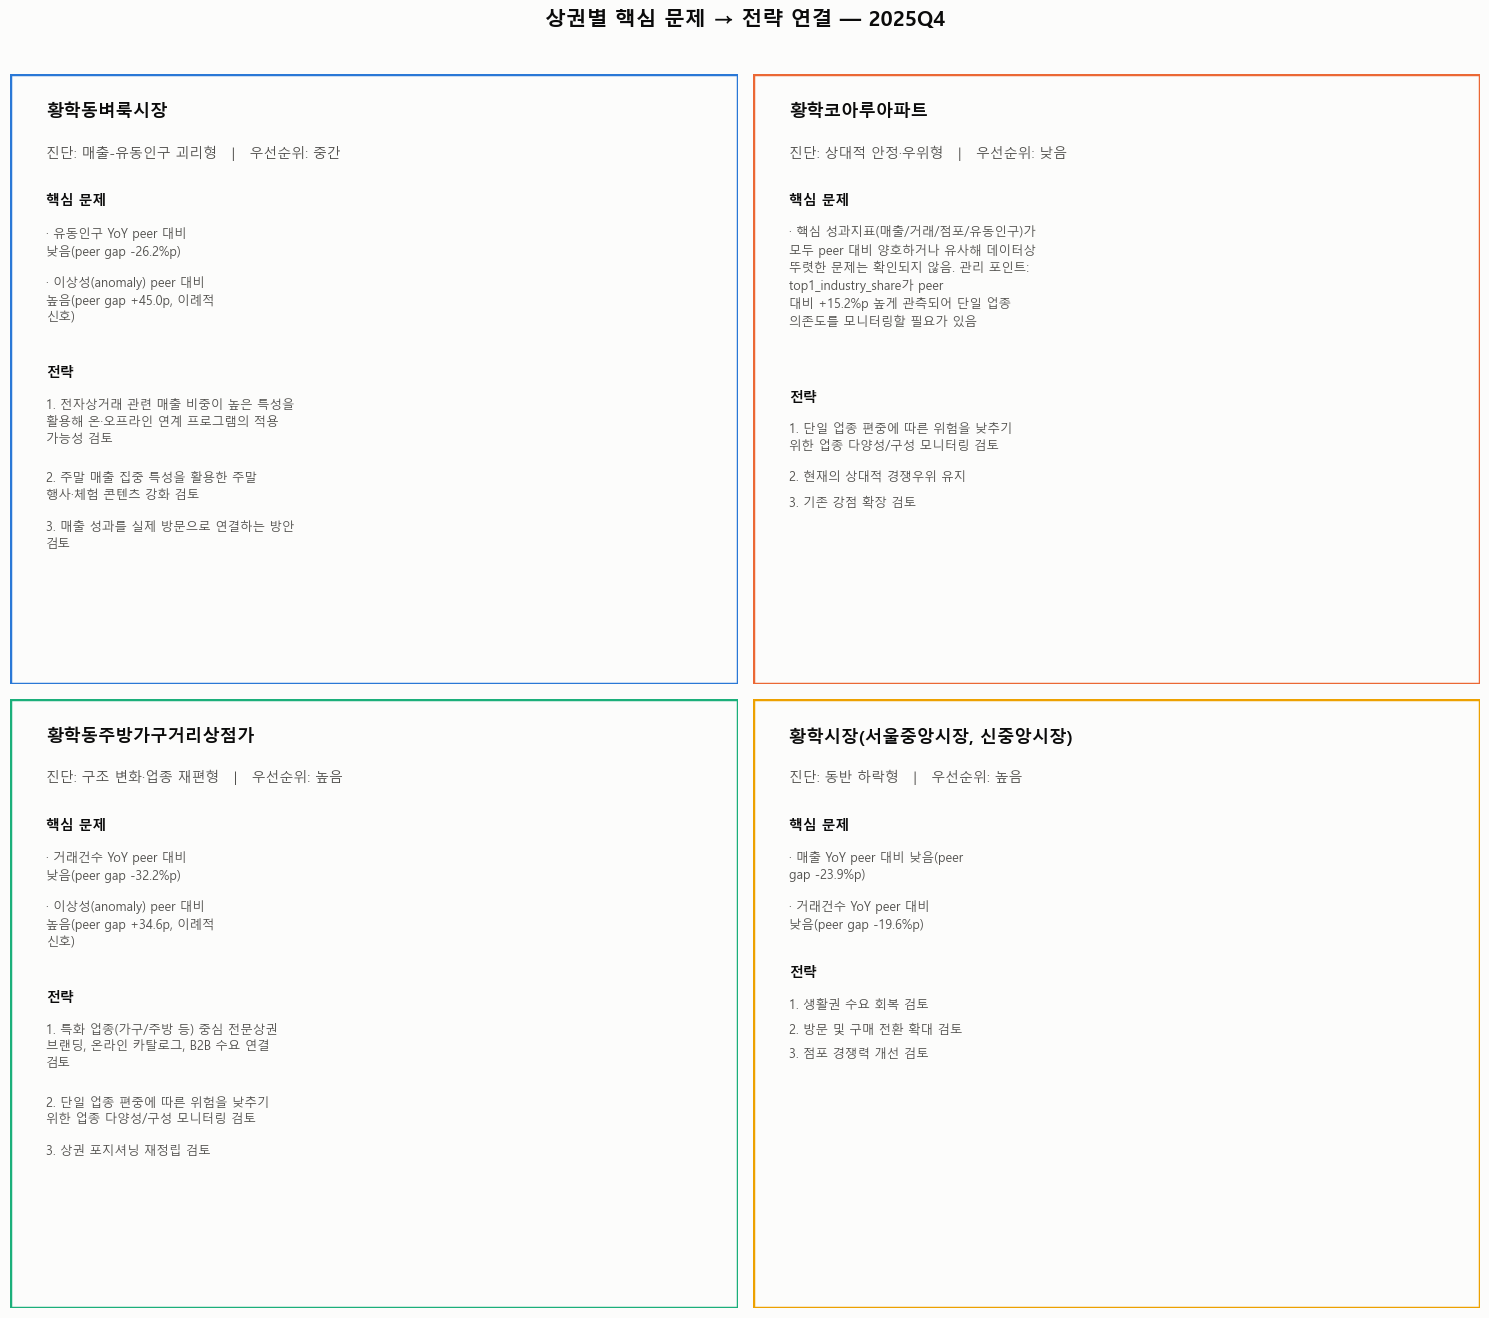

In [18]:
# 카드 안에서 텍스트 블록 하나를 그리고, 실제로 소비한 줄 수만큼만 y를 내려서 다음 요소를
# 그릴 위치를 돌려준다(고정 간격이 아니라 "실제 줄 수 기반" 가변 간격).
CARD_WRAP_WIDTH = 25       # 핵심 문제/전략 본문 줄바꿈 폭(문자 수)
CARD_TITLE_SIZE = 12.5
CARD_HEADER_SIZE = 10
CARD_BODY_SIZE = 9
CARD_HEADER_LINE_UNIT = 0.052   # 제목/헤더 한 줄이 차지하는 y 높이(axes fraction)
CARD_BODY_LINE_UNIT = 0.040     # 본문 한 줄이 차지하는 y 높이(axes fraction)


def draw_card_text(ax, y, text, fontsize, weight, color, wrap=True, width=CARD_WRAP_WIDTH):
    display_text = wrap_text(text, width=width) if wrap else text
    n_lines = display_text.count("\n") + 1
    ax.text(0.05, y, display_text, fontsize=fontsize, fontweight=weight, color=color,
            transform=ax.transAxes, va="top", linespacing=1.4, clip_on=True)
    line_unit = CARD_HEADER_LINE_UNIT if fontsize >= CARD_HEADER_SIZE else CARD_BODY_LINE_UNIT
    return y - line_unit * n_lines


fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for ax, code_ in zip(axes, AREA_ORDER):
    row = strategy_df.set_index(AREA_CODE_COL).loc[code_]
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                            facecolor=SURFACE_COLOR, edgecolor=AREA_COLOR_MAP[code_], linewidth=2.5))

    # 위계: 상권명(제목) > 진단/우선순위 > "핵심 문제"/"전략" 헤더 > 본문
    y = 0.95
    y = draw_card_text(ax, y, AREA_NAME_MAP[code_], CARD_TITLE_SIZE, "bold", INK_PRIMARY, wrap=False)
    y -= 0.015
    y = draw_card_text(ax, y, f"진단: {row['diagnosis_type']}   |   우선순위: {row['priority_level']}",
                        CARD_HEADER_SIZE, "normal", INK_SECONDARY, width=34)
    y -= 0.03

    y = draw_card_text(ax, y, "핵심 문제", CARD_HEADER_SIZE, "bold", INK_PRIMARY, wrap=False)
    for key in ["main_issue_1", "main_issue_2"]:
        val = row.get(key)
        if pd.notna(val) and str(val).strip() not in ("", "-"):
            y = draw_card_text(ax, y, f"· {val}", CARD_BODY_SIZE, "normal", INK_SECONDARY)
    y -= 0.03

    y = draw_card_text(ax, y, "전략", CARD_HEADER_SIZE, "bold", INK_PRIMARY, wrap=False)
    for i in [1, 2, 3]:
        strat = row.get(f"strategy_{i}")
        if pd.notna(strat):
            y = draw_card_text(ax, y, f"{i}. {strat}", CARD_BODY_SIZE, "normal", INK_SECONDARY)

    # 카드 내용이 카드 하단을 넘어가지 않는지 프로그램적으로 확인한다(넘어가면 clip_on=True가
    # 실제 렌더링에서는 잘라내지만, 여기서는 그런 상황 자체가 없는지 명시적으로 검증한다).
    assert y > 0.0, f"{AREA_NAME_MAP[code_]} 카드 내용이 카드 영역을 벗어날 수 있습니다(y={y:.3f})."

fig.suptitle("상권별 핵심 문제 → 전략 연결 — 2025Q4", fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
save_fig(fig, "07_strategy_summary.png")
plt.show()

## 11. Figure 8 — KPI Monitoring Framework

**사용 컬럼**: `strategy_df`의 `outcome_kpi_1~3`, `diagnostic_kpi_1~3`과 그 KPI가 실제로
가리키는 값(예: `outcome_kpi_1`이 `"sales_yoy"`이면 `strategy_df["sales_yoy"]`), 그리고
`benchmark_df`의 `{kpi}_peer_flag` (모두 07/06 결과 그대로 사용, 새 KPI 추가 없음).

- **Outcome KPI**: 정책 실행 이후 실제 성과 변화를 추적하는 지표.
- **Diagnostic/Monitoring KPI**: 상권의 이상성·구조 변화·괴리 상태를 추적하는 지표.

발표 자료에서는 `population_yoy`처럼 Python 변수명이 그대로 노출되지 않도록
`KPI_DISPLAY_NAMES`로 한글 이름을 붙이고, 이미 존재하는 값에서 안전하게 계산할 수 있는
"현재값"과 "관리 방향"을 함께 보여준다. 관리 방향은 ① outcome KPI(YoY류)는 값의 부호,
② diagnostic KPI는 `{kpi}_peer_flag`(HIGH/TYPICAL/LOW)가 있으면 그 값을 그대로 표시한
것이며, **새로운 목표 수치나 정책 효과를 만들어내지 않는다.**

상권마다 KPI 개수가 다를 수 있으므로 결측은 자연스럽게 제외한다.

In [19]:
# outcome_kpi_1~3 / diagnostic_kpi_1~3에 실제로 등장하는 모든 컬럼명에 대한 한글 표시 이름.
# 07/06에 없는 값을 새로 만드는 것이 아니라, 이미 있는 컬럼명을 사람이 읽기 쉬운 이름으로만
# 바꿔 보여준다.
KPI_DISPLAY_NAMES = {
    "sales_yoy": "매출 증감률",
    "transactions_yoy": "거래건수 증감률",
    "stores_yoy": "점포수 증감률",
    "population_yoy": "유동인구 증감률",
    "structural_change_score": "구조 변화 강도 점수",
    "decoupling_score": "매출-유동인구 괴리 점수",
    "anomaly_percentile": "이상 변화 상대 점수",
    "change_intensity_score": "종합 변화 강도 점수",
    "ecommerce_sales_share": "전자상거래 매출 비중",
    "top1_industry_share": "1위 업종 매출 비중",
    "furniture_sales_share": "가구·주방 업종 매출 비중",
    "korean_food_sales_share": "한식 업종 매출 비중",
    "weekend_sales_share": "주말 매출 비중",
    "evening_night_sales_share": "저녁·야간 매출 비중",
}

SCORE_KPI_COLS = ["structural_change_score", "decoupling_score", "anomaly_percentile", "change_intensity_score"]
SHARE_KPI_COLS = [
    "ecommerce_sales_share", "top1_industry_share", "furniture_sales_share",
    "korean_food_sales_share", "weekend_sales_share", "evening_night_sales_share",
]


# KPI 종류에 맞는 단위로 "현재값"을 표시한다(YoY -> %, share -> %, score -> 점).
# YoY·score는 strategy_df에, share류 도메인 feature는 benchmark_df(=bm_indexed)에 있다.
def format_kpi_value(kpi_name, area_code):
    if kpi_name in YOY_COLS or kpi_name in SCORE_KPI_COLS:
        value = strategy_df.set_index(AREA_CODE_COL).loc[area_code, kpi_name]
        return format_pct(value) if kpi_name in YOY_COLS else format_score(value)
    if kpi_name in SHARE_KPI_COLS:
        value = bm_indexed.loc[area_code, kpi_name]
        return ratio_to_pct(value)
    return "N/A"


# 이미 존재하는 값(YoY 부호, peer_flag)만으로 안전하게 계산되는 관리 방향.
# 새로운 목표치·threshold를 만들지 않는다.
def kpi_direction(kpi_name, area_code):
    if kpi_name in YOY_COLS:
        value = strategy_df.set_index(AREA_CODE_COL).loc[area_code, kpi_name]
        return "증가 흐름 관찰" if value >= 0 else "감소 흐름 관찰"
    flag_col = f"{kpi_name}_peer_flag"
    if flag_col in bm_indexed.columns:
        flag = bm_indexed.loc[area_code, flag_col]
        return f"peer 대비 {flag}"
    return "모니터링 지표"


def kpi_line(kpi_name, area_code):
    display_name = KPI_DISPLAY_NAMES.get(kpi_name, kpi_name)
    return f"{display_name}: {format_kpi_value(kpi_name, area_code)} ({kpi_direction(kpi_name, area_code)})"


fig8_rows = []
for code_ in AREA_ORDER:
    row = strategy_df.set_index(AREA_CODE_COL).loc[code_]
    outcome_kpis = [row.get(f"outcome_kpi_{i}") for i in [1, 2, 3]]
    outcome_kpis = [k for k in outcome_kpis if pd.notna(k)]
    diagnostic_kpis = [row.get(f"diagnostic_kpi_{i}") for i in [1, 2, 3]]
    diagnostic_kpis = [k for k in diagnostic_kpis if pd.notna(k)]
    fig8_rows.append({
        "상권": AREA_NAME_MAP[code_],
        "Outcome KPI": "\n".join(kpi_line(k, code_) for k in outcome_kpis),
        "Diagnostic KPI": "\n".join(kpi_line(k, code_) for k in diagnostic_kpis),
    })

fig8_df = pd.DataFrame(fig8_rows)
assert (fig8_df["Outcome KPI"].str.len() > 0).all(), "outcome KPI가 없는 상권이 있습니다."
assert (fig8_df["Diagnostic KPI"].str.len() > 0).all(), "diagnostic KPI가 없는 상권이 있습니다."
fig8_df

,상권,Outcome KPI,Diagnostic KPI
0,황학동벼룩시장,유동인구 증감률: -30.2% (감소 흐름 관찰)\n매출 증감률: +74.3% (증가 흐름 관찰)\n거래건수 증감률: +17.0% (증가 흐름 관찰),매출-유동인구 괴리 점수: 79.6점 (peer 대비 HIGH)\n이상 변화 상대 점수: 99.1점 (peer 대비 HIGH)\n전자상거래 매출 비중: 79.8% (모니터링 지표)
1,황학코아루아파트,매출 증감률: +12.9% (증가 흐름 관찰)\n유동인구 증감률: +3.5% (증가 흐름 관찰)\n거래건수 증감률: +19.4% (증가 흐름 관찰),구조 변화 강도 점수: 37.3점 (peer 대비 LOW)\n이상 변화 상대 점수: 44.4점 (peer 대비 TYPICAL)\n1위 업종 매출 비중: 59.9% (모니터링 지표)
2,황학동주방가구거리상점가,거래건수 증감률: -24.7% (감소 흐름 관찰)\n매출 증감률: -14.2% (감소 흐름 관찰)\n점포수 증감률: +2.6% (증가 흐름 관찰),구조 변화 강도 점수: 70.9점 (peer 대비 HIGH)\n이상 변화 상대 점수: 88.8점 (peer 대비 HIGH)\n가구·주방 업종 매출 비중: 56.9% (모니터링 지표)
3,"황학시장(서울중앙시장, 신중앙시장)",유동인구 증감률: -14.1% (감소 흐름 관찰)\n매출 증감률: -18.1% (감소 흐름 관찰)\n점포수 증감률: -2.7% (감소 흐름 관찰),구조 변화 강도 점수: 39.9점 (peer 대비 TYPICAL)\n이상 변화 상대 점수: 12.3점 (peer 대비 LOW)\n종합 변화 강도 점수: 42.1점 (peer 대비 TYPICAL)


저장: ..\reports\figures\08_kpi_framework.png


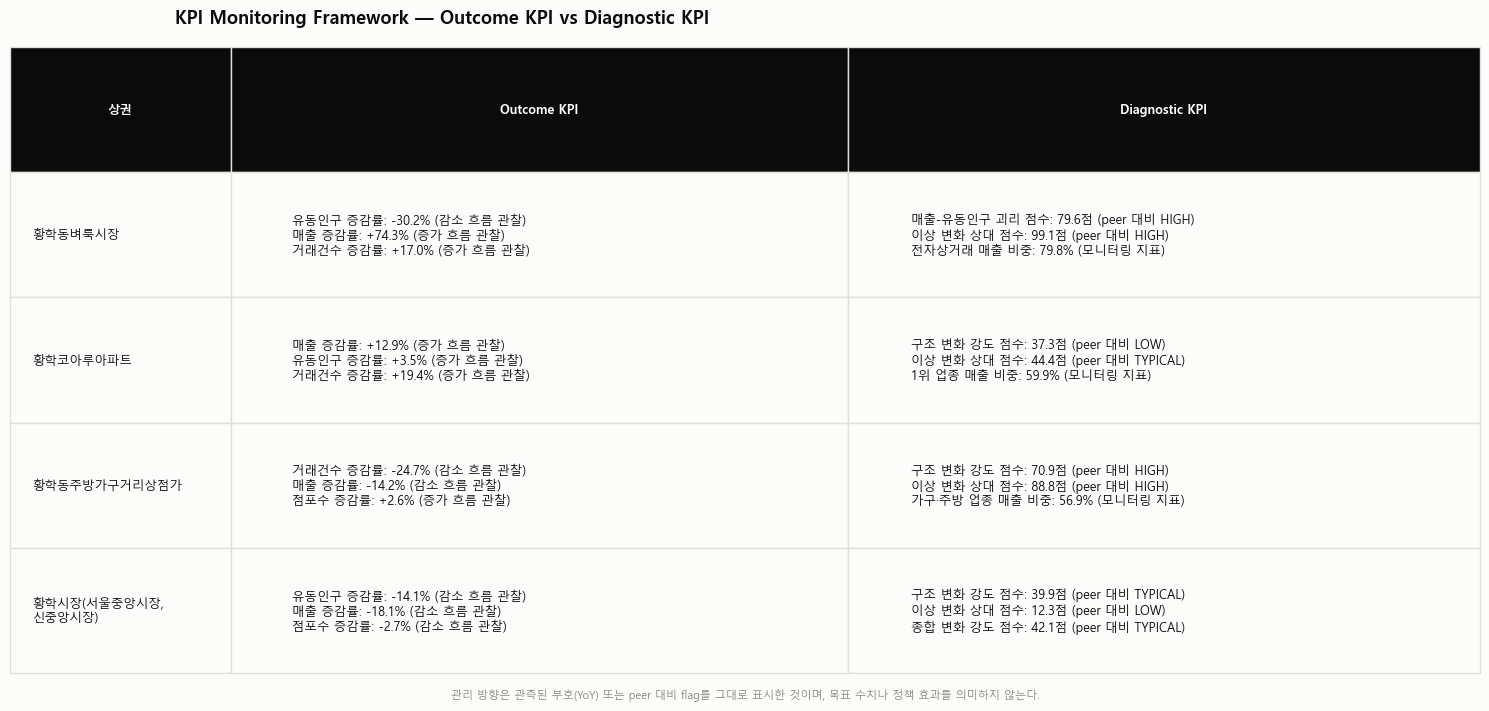

In [20]:
# 상권명이 길어 표 첫 컬럼에서 옆 컬럼 배경에 가려질 수 있으므로, 표시용으로만 줄바꿈한다(값 자체는 fig8_df에 그대로 유지).
fig8_display = fig8_df.copy()
fig8_display["상권"] = fig8_display["상권"].apply(lambda name: wrap_text(name, width=12))

fig, ax = plt.subplots(figsize=(15, 6.5))
ax.axis("off")
table = ax.table(cellText=fig8_display.values, colLabels=fig8_display.columns, cellLoc="left", loc="center",
                  colWidths=[0.15, 0.42, 0.43])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 6.5)

for (row, _col), cell in table.get_celld().items():
    cell.set_edgecolor(GRID_COLOR)
    if row == 0:
        cell.set_facecolor(INK_PRIMARY)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(SURFACE_COLOR)

fig.tight_layout()
# 큰 table.scale() 값이 axes 상단을 넘어서면 ax.set_title이 가려질 수 있어,
# 항상 모든 artist 위에 그려지는 figure-level suptitle을 사용한다.
fig.suptitle("KPI Monitoring Framework — Outcome KPI vs Diagnostic KPI",
             fontsize=13, fontweight="bold", x=0.12, y=1.04, ha="left")
fig.text(0.5, -0.02,
         "관리 방향은 관측된 부호(YoY) 또는 peer 대비 flag를 그대로 표시한 것이며, 목표 수치나 정책 효과를 의미하지 않는다.",
         ha="center", fontsize=8, color=INK_MUTED)
save_fig(fig, "08_kpi_framework.png")
plt.show()

## 12. 최종 한 장 요약

발표자료 한 장에 바로 사용할 수 있는 infographic-like 요약이다. 새로운 값을 계산하지
않고 앞선 section에서 이미 사용한 값만 재배치한다. 가독성을 위해 전략은
`strategy_1`, `strategy_2`까지만 표시하며(전체 3개는 Figure 7에서 이미 확인했다),
패널 테두리 색은 `priority_level`을 따른다.

저장: ..\reports\figures\09_final_summary.png


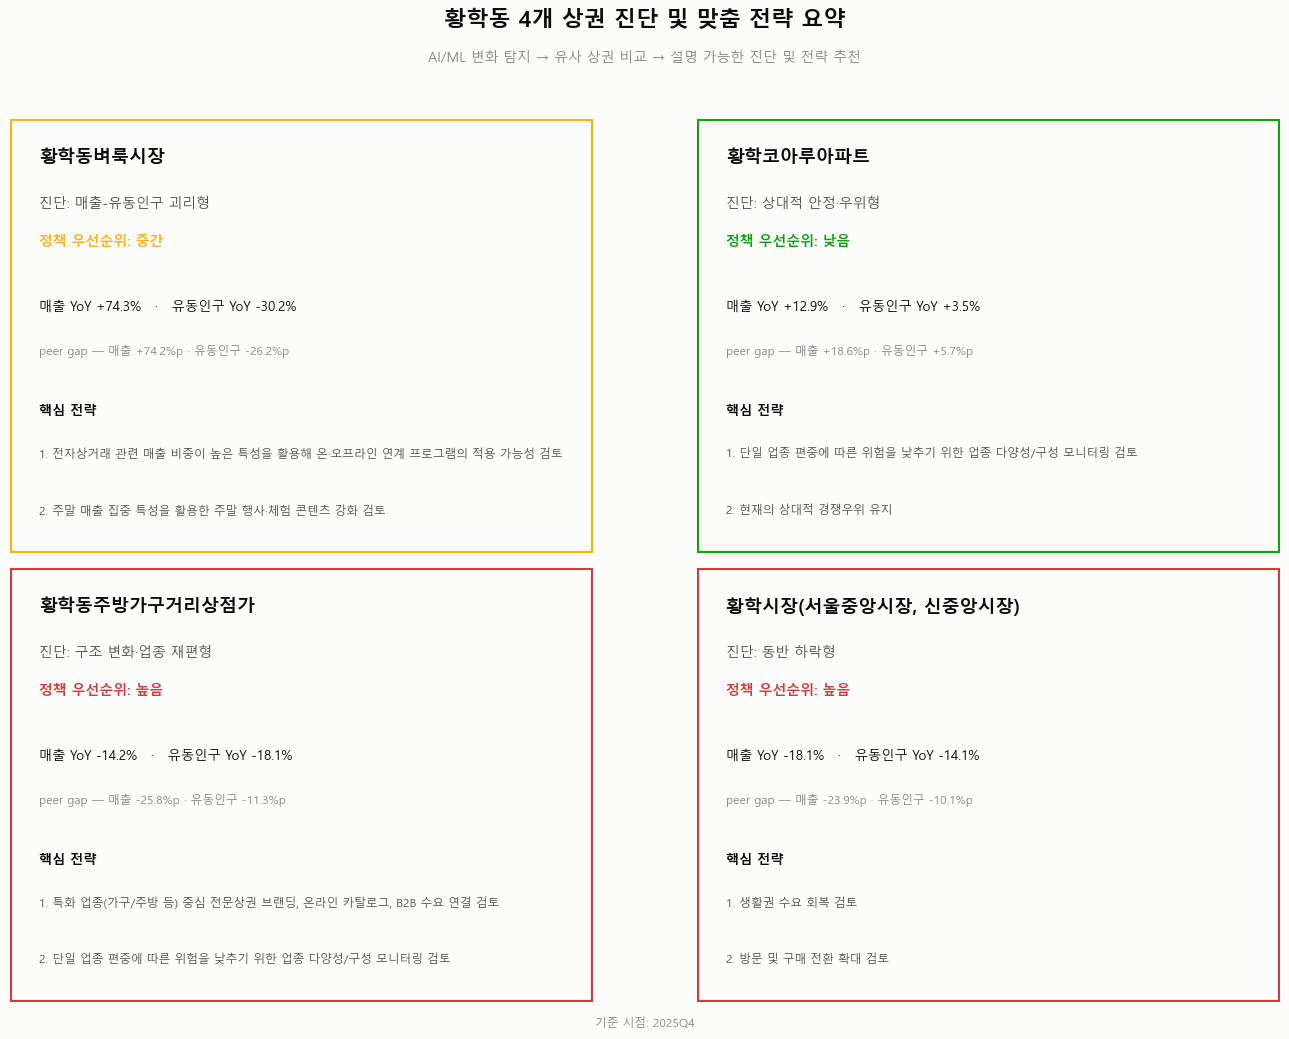

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
axes = axes.flatten()

for ax, code_ in zip(axes, AREA_ORDER):
    row = strategy_df.set_index(AREA_CODE_COL).loc[code_]
    border_color = PRIORITY_COLORS.get(row["priority_level"], INK_MUTED)
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                            facecolor=SURFACE_COLOR, edgecolor=border_color, linewidth=3))

    ax.text(0.05, 0.93, AREA_NAME_MAP[code_], fontsize=13, fontweight="bold",
            color=INK_PRIMARY, transform=ax.transAxes, va="top")
    ax.text(0.05, 0.82, f"진단: {row['diagnosis_type']}",
            fontsize=10, color=INK_SECONDARY, transform=ax.transAxes, va="top")
    ax.text(0.05, 0.73, f"정책 우선순위: {row['priority_level']}",
            fontsize=10, color=border_color, fontweight="bold", transform=ax.transAxes, va="top")

    ax.text(0.05, 0.58,
            f"매출 YoY {format_pct(row['sales_yoy'])}   ·   유동인구 YoY {format_pct(row['population_yoy'])}",
            fontsize=9.5, color=INK_PRIMARY, transform=ax.transAxes, va="top")
    ax.text(0.05, 0.48,
            f"peer gap — 매출 {format_pp(row['sales_yoy_peer_gap'])} · 유동인구 {format_pp(row['population_yoy_peer_gap'])}",
            fontsize=8.5, color=INK_MUTED, transform=ax.transAxes, va="top")

    ax.text(0.05, 0.34, "핵심 전략", fontsize=9.5, fontweight="bold", color=INK_PRIMARY,
            transform=ax.transAxes, va="top")
    y = 0.24
    for i in [1, 2]:
        strat = row.get(f"strategy_{i}")
        if pd.notna(strat):
            ax.text(0.05, y, f"{i}. {strat}", fontsize=8.5, color=INK_SECONDARY,
                    transform=ax.transAxes, va="top")
            y -= 0.13

fig.suptitle("황학동 4개 상권 진단 및 맞춤 전략 요약", fontsize=16, fontweight="bold", y=1.06)
fig.text(0.5, 1.005, "AI/ML 변화 탐지 → 유사 상권 비교 → 설명 가능한 진단 및 전략 추천",
         ha="center", fontsize=10, color=INK_MUTED)
fig.text(0.5, -0.01, "기준 시점: 2025Q4", ha="center", fontsize=8.5, color=INK_MUTED)
fig.tight_layout()
save_fig(fig, "09_final_summary.png")
plt.show()

## 13. Validation

07/06 결과를 변경하지 않았는지, figure가 실제로 저장됐는지 마지막으로 확인한다. 이번
시각화 개선(색상 분리, Figure 4/7/8 재구성 등)이 **분석값 자체는 전혀 건드리지 않았음**을
CSV 재로드 비교로 명시적으로 검증한다.

In [22]:
# 1) 최종 데이터 구조 검증
assert strategy_df.shape[0] == 4
assert strategy_df[AREA_CODE_COL].nunique() == 4
assert strategy_df["diagnosis_type"].isna().sum() == 0
assert strategy_df["priority_level"].isna().sum() == 0
for col in ["strategy_1", "strategy_2", "strategy_3"]:
    assert strategy_df[col].isna().sum() == 0
assert (fig8_df["Outcome KPI"].str.len() > 0).all()
assert (fig8_df["Diagnostic KPI"].str.len() > 0).all()

# 2) 07 결과 대비 전체 컬럼 값 불변 검증(재로드 후 비교) — diagnosis/priority/strategy 뿐 아니라
#    AI/ML signal, YoY, peer gap 등 모든 컬럼이 그대로인지 확인한다.
reloaded_strategy = pd.read_csv(STRATEGY_PATH, encoding="utf-8-sig")
assert reloaded_strategy.shape == strategy_df.shape
assert list(reloaded_strategy[AREA_CODE_COL]) == list(strategy_df[AREA_CODE_COL])
assert reloaded_strategy["diagnosis_type"].equals(strategy_df["diagnosis_type"]), "diagnosis_type이 변경되었습니다."
assert reloaded_strategy["priority_level"].equals(strategy_df["priority_level"]), "priority_level이 변경되었습니다."
for col in ["strategy_1", "strategy_2", "strategy_3", "strategy_basis_1", "strategy_basis_2", "strategy_basis_3"]:
    assert reloaded_strategy[col].equals(strategy_df[col]), f"{col}이 변경되었습니다."
for col in SCORE_COLS:  # structural_change_score, decoupling_score, anomaly_percentile, change_intensity_score
    assert reloaded_strategy[col].equals(strategy_df[col]), f"AI/ML signal({col})이 변경되었습니다."
for col in YOY_COLS:
    assert reloaded_strategy[col].equals(strategy_df[col]), f"YoY 지표({col})가 변경되었습니다."

# 3) 06 Peer Benchmark 결과도 그대로인지 재로드 비교로 확인한다.
reloaded_benchmark = pd.read_csv(BENCHMARK_PATH, encoding="utf-8-sig")
assert reloaded_benchmark.shape == benchmark_df.shape
assert reloaded_benchmark.equals(benchmark_df), "hwanghak_peer_benchmark.csv 값이 변경되었습니다."

# 4) 저장된 figure 존재 및 크기 확인
assert len(saved_figures) == 9, f"저장된 figure 수가 9개가 아닙니다: {len(saved_figures)}"
for path in saved_figures:
    assert path.exists(), f"figure 파일이 존재하지 않습니다: {path}"
    assert path.stat().st_size > 0, f"figure 파일 크기가 0입니다: {path}"

print("전체 validation 통과 (분석값 불변 + figure 저장 확인)")
print(f"저장된 figure 수: {len(saved_figures)}")
for path in saved_figures:
    print(" -", path.name, f"({path.stat().st_size / 1024:.1f} KB)")

전체 validation 통과 (분석값 불변 + figure 저장 확인)
저장된 figure 수: 9
 - 01_hwanghak_yoy_performance.png (179.9 KB)
 - 02_target_vs_peer.png (283.6 KB)
 - 03_peer_gap_heatmap.png (145.2 KB)
 - 04_ai_signal_comparison.png (253.9 KB)
 - 05_diagnosis_map.png (201.9 KB)
 - 06_diagnosis_priority_summary.png (130.9 KB)
 - 07_strategy_summary.png (582.0 KB)
 - 08_kpi_framework.png (475.1 KB)
 - 09_final_summary.png (421.1 KB)


## 14. 최종 요약

### 최종 분석 메시지

1. 황학동 4개 상권은 동일 지역 내에서도 성과 변화 패턴이 서로 다르게 관측된다.
   황학동벼룩시장은 매출 YoY +74.3%로 가장 크게 증가했지만 유동인구 YoY는 -30.2%로
   가장 크게 감소했고, 황학코아루아파트는 매출·거래건수·유동인구가 모두 양(+)의
   방향을 보이며, 황학동주방가구거리상점가와 황학시장은 대부분의 핵심 지표가 음(-)의
   방향으로 나타난다.
2. 단순 YoY뿐 아니라 구조적으로 유사한 peer와 비교했을 때 상대적 위치가 더
   명확해진다. 황학코아루아파트의 매출 YoY(+12.9%)는 절댓값으로는 작아 보이지만
   peer median 대비로는 +18.6%p 높게 나타난다.
3. AI/ML change signal에서도 문제 유형이 다르게 나타난다. 황학동벼룩시장은
   `anomaly_percentile` 99.1·`decoupling_score` 79.6으로 이례적 변화·괴리가 가장
   크게 관측되고, 황학동주방가구거리상점가는 `structural_change_score` 70.9로
   구조 변화 강도가 가장 크게 관측된다.
4. 최종 diagnosis에 따라 상권별 정책 우선순위와 전략 방향이 달라진다
   (황학동벼룩시장: 매출-유동인구 괴리형/중간, 황학코아루아파트: 상대적
   안정·우위형/낮음, 황학동주방가구거리상점가: 구조 변화·업종 재편형/높음,
   황학시장: 동반 하락형/높음).
5. 따라서 황학동 전체에 동일한 활성화 정책을 적용하기보다는 상권별로 서로 다른
   전략(`strategy_1~3`)과 KPI를 적용하는 맞춤 접근을 검토할 수 있다.

### 해석상 주의점

- Peer benchmark는 observational/descriptive comparison이며 causal effect가 아니다.
- Nearest Neighbor는 비교 가능한 상권을 찾기 위한 도구이지 정답 peer를 보장하지 않는다.
- Isolation Forest anomaly는 변화의 이례성을 탐지하며 좋은/나쁜 상태를 직접 의미하지
  않는다.
- Rule-based diagnosis와 strategy recommendation은 설명 가능한 의사결정 지원
  규칙이며 학습된 정책 최적화 모델이 아니다.
- 실제 정책 실행 전에는 현장조사, 상인 인터뷰, 정책 환경 검토가 필요하다.

### AI/ML 활용 구조

```text
상권 데이터
    ↓
Feature Engineering
    ↓
Isolation Forest — 이상 변화 탐지
AI/ML Signal 계산 — 변화 특성 정량화(구조 변화·괴리·변동성 등)
    ↓
Nearest Neighbor — 유사 상권 탐색
    ↓
Peer Benchmark — 상대 성과 비교
    ↓
Rule-based Diagnosis — 설명 가능한 상권 진단
    ↓
Domain-based Strategy Mapping — 상권별 정책 전략 연결
    ↓
Final Visualization — 의사결정 지원
```

본 프로젝트에서 AI/ML은 다수의 상권 변화 지표에서 사람이 직접 찾기 어려운 이상성·구조
변화·유사 상권 관계를 탐지하고 정량화하는 데 활용되며, 그 결과를 설명 가능한 Rule-based
진단과 전략으로 연결한다. **AI가 정책을 자동으로 생성하는 것이 아니라**, AI/ML이
정량화한 신호를 사람이 설계한 규칙(threshold, diagnosis 분류, strategy mapping)과
결합해 의사결정을 지원하는 구조다.